# Tutorial 10: Comparing Brain Areas

Tutorial 9 asked what one population knows about behaviour. This one asks how
areas relate to each other, using Allen Brain Observatory recordings from three
regions under two conditions.

The data is a better fit for temporal questions than Tutorial 9's: it is a
continuously sampled regular grid with no gaps, so quantities that slide a
window along the index are safe here.

| | |
|---|---|
| **Regions** | VISp (primary visual), VISpm (secondary visual), CA1 (hippocampus) |
| **Conditions** | natural movie, spontaneous activity |
| **Format** | spike counts binned at 20 ms |

| # | Question | What we expect, and why |
|---|---|---|
| 1 | Do regions couple internally more than mutually? | Local circuitry is denser than long-range projections, so yes. |
| 2 | Does coupling reorganise with the stimulus? | A shared visual drive should couple the visual areas during the movie. |
| 3 | Do regions differ in intrinsic timescale? | Hierarchical accounts predict longer timescales further from sensory input. |
| 4 | Does timescale change with the stimulus? | A structured input could impose its own temporal structure. |

**Three of these four come back negative.** The notebook is largely about how
you establish that, and about two ways of getting them wrong that produce
convincing-looking positives.

**Runtime** is around forty minutes. Everything is measured with three repeats,
neurons drawn at random and equalised across regions, and the estimator's own
error bars used to decide what counts.

## 0. Setup

In [1]:
import logging
import time
import numpy as np
import matplotlib.pyplot as plt
import neural_mi as nmi
from neural_mi import quantities as q

logging.getLogger('neural_mi').setLevel(logging.WARNING)

SCALE = 1
REGIONS = ('VISp', 'VISpm', 'CA1')
CONDITIONS = ('nat_movie', 'spont')
T = int(20000 * SCALE)
BIN_MS = 20
REPS = (0, 1, 2)

FILES = {('nat_movie', 'VISp'): 'nat_movie_visp_20.npy',
         ('nat_movie', 'VISpm'): 'nat_movie_vispm_20.npy',
         ('nat_movie', 'CA1'): 'nat_movie_ca1_20.npy',
         ('spont', 'VISp'): 'spont_visp_20.npy',
         ('spont', 'VISpm'): 'spont_vispm_20.npy',
         ('spont', 'CA1'): 'spont_ca1_20.npy'}

def load(cond, reg, n_units=None, draw=0):
    a = np.load('data/' + FILES[(cond, reg)]).astype('float32')[:T]
    if n_units is None or n_units >= a.shape[1]:
        return a
    rng = np.random.default_rng(900 + draw)
    return a[:, np.sort(rng.permutation(a.shape[1])[:n_units])]   # RANDOM draw

for cond in CONDITIONS:
    sizes = {r: np.load('data/' + FILES[(cond, r)]).shape for r in REGIONS}
    print(f"{cond:<10} " + "   ".join(f"{r}: {s[1]} units" for r, s in sizes.items()))
N_EQ = min(np.load('data/' + FILES[(c, r)]).shape[1] for c in CONDITIONS for r in REGIONS)
print(f"\nequalising every region to {N_EQ} units, drawn at random")

nat_movie  VISp: 100 units   VISpm: 64 units   CA1: 100 units
spont      VISp: 100 units   VISpm: 64 units   CA1: 100 units

equalising every region to 64 units, drawn at random


**Regions have different unit counts**, and that matters more than it looks.
Mutual information grows with the number of channels observed, so comparing a
100-unit region against a 64-unit one partly compares how many units each probe
happened to catch. Everything below equalises to the smallest count, drawing at
random rather than by activity.

## 1. Question 1: do regions couple internally more than mutually?

`mode='pairwise'` computes MI between every pair of channels. Stack a few units
from each region into one channel set and the matrix has **block structure**:
within-region blocks on the diagonal, between-region blocks off it.

Before the result, the mistake that makes it look far more impressive than it
is.

In [2]:
N_PER = 8
W_PAIR = 10

def block_means(M, n):
    out = {}
    for i, a in enumerate(REGIONS):
        for j, b in enumerate(REGIONS):
            if j < i:
                continue
            sub = M[i*n:(i+1)*n, j*n:(j+1)*n]
            vals = sub[np.triu_indices(n, 1)] if i == j else sub.ravel()
            out[f'{a}-{b}'] = float(np.mean(vals))
    return out

def pairwise_blocks(cond, draw, by_variance=False):
    mats = []
    for r in REGIONS:
        a = np.load('data/' + FILES[(cond, r)]).astype('float32')[:T]
        if by_variance:                      # the WRONG way, shown for contrast
            idx = np.sort(np.argsort(-a.var(axis=0))[:N_PER])
        else:                                # random draw
            rng = np.random.default_rng(900 + draw)
            idx = np.sort(rng.permutation(a.shape[1])[:N_PER])
        mats.append(a[:, idx])
    stack = np.hstack(mats)
    res = nmi.run(stack, mode='pairwise',
                  processing=nmi.Processing(x='continuous',
                                            x_params={'window_size': W_PAIR,
                                                      'step_size': W_PAIR}),
                  training=nmi.Training(n_epochs=int(60 * SCALE), patience=20),
                  model=nmi.Model(embedding_model='mlp', embedding_dim=8, hidden_dim=64),
                  n_workers=10, seed=draw, show_progress=False)
    return block_means(np.asarray(res.details['mi_matrix']), N_PER)

t0 = time.time()
biased = pairwise_blocks('nat_movie', 0, by_variance=True)
random0 = pairwise_blocks('nat_movie', 0, by_variance=False)
print(f"natural movie, {N_PER} units per region, one draw   ({time.time()-t0:.0f}s)\n")
print(f"  {'block':<14}{'most active':>13}{'random':>10}{'ratio':>8}")
for k in biased:
    print(f"  {k:<14}{biased[k]:>13.4f}{random0[k]:>10.4f}{biased[k]/max(random0[k],1e-9):>8.1f}x")

2026-08-27 03:40:12 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopp

neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


...

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0002 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0001 nats at epoch 7). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


natural movie, 8 units per region, one draw   (266s)

  block           most active    random   ratio
  VISp-VISp            0.5742    0.0198    29.0x
  VISp-VISpm           0.1458    0.0081    18.0x
  VISp-CA1             0.0215    0.0051     4.2x
  VISpm-VISpm          0.2783    0.0393     7.1x
  VISpm-CA1            0.0267    0.0172     1.6x
  CA1-CA1              0.1227    0.0257     4.8x


**Selecting the most active units inflates pairwise coupling by roughly an order
of magnitude.** Every block. The selection is on variance, which is correlated
with how much a unit can share with anything, so it selects for exactly the
quantity being measured.

This is the single easiest way to produce a dramatic and wrong result from this
analysis, and nothing in the output warns you. Draw at random.

Now the actual measurement, with three independent draws so each block carries
an error bar.

In [3]:
pair_res = {}
for cond in CONDITIONS:
    draws = []
    for draw in REPS:
        t0 = time.time()
        draws.append(pairwise_blocks(cond, draw))
        print(f"  {cond} draw{draw} ({time.time()-t0:.0f}s)")
    keys = draws[0].keys()
    pair_res[cond] = {k: (float(np.mean([d[k] for d in draws])),
                          float(np.std([d[k] for d in draws], ddof=1))) for k in keys}
    within = [np.mean([d[f'{r}-{r}'] for r in REGIONS]) for d in draws]
    between = [np.mean([v for k, v in d.items() if k.split('-')[0] != k.split('-')[1]])
               for d in draws]
    pair_res[cond + '_ratios'] = [float(w/b) for w, b in zip(within, between)]

print()
for cond in CONDITIONS:
    print(f"--- {cond}")
    for k, (m, s) in pair_res[cond].items():
        print(f"    {k:<14} {m:.4f} +/- {s:.4f}")
    rr = pair_res[cond + '_ratios']
    print(f"    within/between per draw: {[round(x,2) for x in rr]}   "
          f"mean {np.mean(rr):.2f}")

2026-08-27 03:44:37 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0001 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 3). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0005 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results =

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0003 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0001 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0002 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


...

neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0000 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0001 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0003 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0001 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(
neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: All test MI values in the training history are non-positive (max test MI = -0.0001 nats at epoch 0). The model failed to learn a generalising representation — this typically indicates too few epochs, too high a learning rate, or degenerate data. Reporting train MI = 0 nats. The raw train MI was 0.0000 nats (likely reflecting overfitting, not true MI). Consider increasing n_epochs, reducing learning_rate, or inspecting data quality.
  results = trainer.train(


neural_mi/analysis/task.py:367: UserWarning: Training completed all 60 epoch(s) without early stopping, and the best (smoothed) test MI occurred at the final epoch. MI may still have been increasing when training stopped, so the reported estimate could be an under-trained lower bound. Consider increasing n_epochs (or lowering patience to enable early stopping).
  results = trainer.train(


  spont draw2 (114s)

--- nat_movie
    VISp-VISp      0.0514 +/- 0.0692
    VISp-VISpm     0.0098 +/- 0.0042
    VISp-CA1       0.0034 +/- 0.0015
    VISpm-VISpm    0.0449 +/- 0.0221
    VISpm-CA1      0.0104 +/- 0.0068
    CA1-CA1        0.0157 +/- 0.0087
    within/between per draw: [2.79, 8.08, 4.3]   mean 5.05
--- spont
    VISp-VISp      0.0373 +/- 0.0451
    VISp-VISpm     0.0091 +/- 0.0059
    VISp-CA1       0.0157 +/- 0.0117
    VISpm-VISpm    0.0199 +/- 0.0079
    VISpm-CA1      0.0196 +/- 0.0085
    CA1-CA1        0.0343 +/- 0.0191
    within/between per draw: [1.34, 3.34, 2.36]   mean 2.35


**Within-region coupling exceeds between-region coupling in every draw, in both
conditions.** That is the answer to question 1, and it is the one robust
coupling result here.

Notice what survived and what did not. The absolute block values collapsed by
seven to fourteen times when the selection bias was removed. The **ratio** barely
moved, because a bias that multiplies every block by a similar factor cancels in
a ratio of aggregates.

**On real data, prefer a contrast to an absolute.** Individual blocks here are
noisy enough that some have a standard deviation comparable to their own mean.
The ratio aggregates six blocks and is correspondingly steadier.

There is a second reason not to quote these block values. Each block averages
over many pairs, and every pair is its own small model trained for 60 epochs.
A large share of them stop with held-out MI still climbing, which the library
flags as an under-trained lower bound. That is tolerable for a contrast, since
the truncation applies to every block alike and largely cancels in a ratio. It
does not license reading `0.0514` as the coupling within VISp. Raising the
epoch budget would raise every block, and the ratio is what would stay put.

## 2. Question 2: does coupling reorganise with the stimulus?

A natural movie drives the visual areas with shared structure, so VISp and VISpm
might couple more strongly during it. The block means differ between conditions,
so it is tempting to read them off. Test them instead.

In [4]:
print(f"  {'block':<14}{'movie':>9}{'spont':>9}{'diff':>9}{'2se':>9}  verdict")
for k in pair_res['nat_movie']:
    m1, s1 = pair_res['nat_movie'][k]
    m2, s2 = pair_res['spont'][k]
    se = np.sqrt(s1**2 + s2**2) / np.sqrt(len(REPS))
    sig = abs(m1 - m2) > 2*se
    print(f"  {k:<14}{m1:>9.4f}{m2:>9.4f}{m1-m2:>+9.4f}{2*se:>9.4f}  "
          f"{'SIGNIFICANT' if sig else 'ns'}")

rm, rs = pair_res['nat_movie_ratios'], pair_res['spont_ratios']
diff = np.mean(rm) - np.mean(rs)
se = np.sqrt(np.var(rm, ddof=1)/len(rm) + np.var(rs, ddof=1)/len(rs))
print(f"\n  within/between ratio: movie {np.mean(rm):.2f}, spont {np.mean(rs):.2f}, "
      f"diff {diff:+.2f} (2se = {2*se:.2f})  "
      f"{'SIGNIFICANT' if abs(diff) > 2*se else 'ns'}")

  block             movie    spont     diff      2se  verdict
  VISp-VISp        0.0514   0.0373  +0.0141   0.0954  ns
  VISp-VISpm       0.0098   0.0091  +0.0006   0.0084  ns
  VISp-CA1         0.0034   0.0157  -0.0123   0.0136  ns
  VISpm-VISpm      0.0449   0.0199  +0.0250   0.0271  ns
  VISpm-CA1        0.0104   0.0196  -0.0092   0.0126  ns
  CA1-CA1          0.0157   0.0343  -0.0186   0.0243  ns

  within/between ratio: movie 5.05, spont 2.35, diff +2.71 (2se = 3.35)  ns


**Nothing survives.** Not one block, and not the ratio.

The ratio is the instructive one. Its per-draw values span a wide range, so
although the two condition means look far apart, the spread across draws is
comparable to the gap between them. Three draws is not enough to resolve it, and
the honest report is that this data does not establish a condition effect on
coupling.

**A difference between two means is not a result until it is compared with its
own noise.** The block means differ; the differences are within the noise. Both
statements are true and only the second is a conclusion.

## 3. Question 3: do regions differ in intrinsic timescale?

Active information storage, `I(X_past(k); X_0)`, asks how much a population's
own recent past predicts its present. Sweeping the history length `k` and
finding where the curve stops improving gives an **intrinsic order**: the number
of past bins that carry usable information.

This works, and it is worth knowing that it works, because Tutorial 5's oracle
version can be checked against a closed form. On autoregressive processes of
known order the method recovers 1, 2, 3 and 4 correctly.

Two decisions matter here, and both were settled by measurement rather than
assumption.

**The decision rule.** Walk up from `k=1`, compare each increment against its
own standard error, and stop at the **first** increment that fails. Taking the
last increment that passes instead lets a single noise excursion inflate the
answer, which on genuinely flat data reported order 5 when the truth was 1.

**Which MI to use.** `mi_estimate` is train-side. Input dimension grows as
`n_channels x k`, so each added lag buys more room to memorise, and train-side
counts that as signal. Held-out MI does not. The two disagree here, and section
5 shows the disagreement.

In [5]:
KS = [1, 2, 3, 4]
AIS_TRAIN = nmi.Training(n_epochs=int(100 * SCALE), patience=30, batch_size=256)
AIS_MODEL = nmi.Model(embedding_model='lru', embedding_dim=32, hidden_dim=256)

def order_of(mean, sd, n):
    det, detail = 1, []
    for i in range(1, len(KS)):
        k, kp = KS[i], KS[i-1]
        inc = mean[k] - mean[kp]
        se = np.sqrt(sd[k]**2 + sd[kp]**2) / np.sqrt(n)
        sig = inc > 2*se
        detail.append(f"k{k}:{inc:+.3f}{'*' if sig else ''}")
        if not sig:
            break
        det = k
    return det, detail

ais = {}
for cond in CONDITIONS:
    for reg in REGIONS:
        sub = load(cond, reg, n_units=N_EQ, draw=0)
        tr_m, tr_s, te_m, te_s = {}, {}, {}, {}
        for k in KS:
            tr, te = [], []
            for rep in REPS:
                r = q.active_information_storage(
                    sub, k=k, future_k=1, training=AIS_TRAIN, model=AIS_MODEL,
                    n_workers=6, seed=rep, show_progress=False)
                tr.append(float(r.mi_estimate)); te.append(float(r.details['test_mi']))
            tr_m[k], tr_s[k] = float(np.mean(tr)), float(np.std(tr, ddof=1))
            te_m[k], te_s[k] = float(np.mean(te)), float(np.std(te, ddof=1))
        d_te, det_te = order_of(te_m, te_s, len(REPS))
        d_tr, _ = order_of(tr_m, tr_s, len(REPS))
        ais[(cond, reg)] = {'test': te_m, 'test_sd': te_s, 'train': tr_m,
                            'order_test': d_te, 'order_train': d_tr}
        print(f"  {cond:<10} {reg:<6} held-out: " + " ".join(det_te) +
              f"   order {d_te}   (train-side would say {d_tr})")

2026-08-27 03:57:13 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:57:44 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:58:16 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:58:47 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 03:59:23 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


...

2026-08-27 04:37:01 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 04:37:39 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 04:38:21 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


2026-08-27 04:39:02 - neural_mi - WARNING - Reproducibility with random_seed is not guaranteed with n_workers > 1.


  spont      CA1    held-out: k2:+0.136* k3:+0.133   order 2   (train-side would say 2)


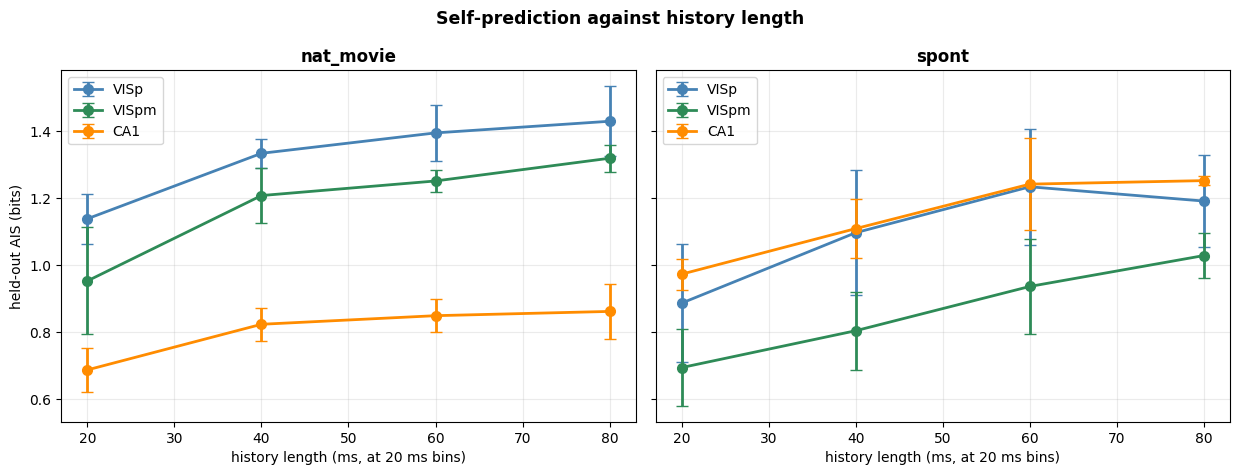

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, cond in zip(axes, CONDITIONS):
    for reg, colour in zip(REGIONS, ('steelblue', 'seagreen', 'darkorange')):
        d = ais[(cond, reg)]
        m = [d['test'][k] for k in KS]; s = [d['test_sd'][k] for k in KS]
        ax.errorbar([k*BIN_MS for k in KS], m, yerr=s, fmt='o-', color=colour,
                    lw=2, ms=7, capsize=4, label=reg)
    ax.set_xlabel(f'history length (ms, at {BIN_MS} ms bins)')
    ax.set_title(cond, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.25); ax.legend()
axes[0].set_ylabel('held-out AIS (bits)')
plt.suptitle('Self-prediction against history length', fontsize=12.5, fontweight='bold')
plt.tight_layout()
plt.show()

**All three regions look the same.** During the movie every region reaches order
2, about 40 ms of usable history at 20 ms bins, and no region stands apart.

Whatever hierarchical differences exist between primary visual cortex,
secondary visual cortex and hippocampus, this measurement does not resolve them.
That is a real answer to question 3, and a negative one.

## 4. Question 4: does timescale change with the stimulus?

The orders in the two conditions are not identical, which invites the reading
that the stimulus extends the timescale. Compare the effect sizes before
believing it.

In [7]:
print(f"  {'cell':<20}{'increment':>11}{'2se':>9}{'verdict':>9}{'order':>7}")
mv, sp = [], []
for cond in CONDITIONS:
    for reg in REGIONS:
        d = ais[(cond, reg)]
        inc = d['test'][2] - d['test'][1]
        se = 2*np.sqrt(d['test_sd'][2]**2 + d['test_sd'][1]**2)/np.sqrt(len(REPS))
        (mv if cond == 'nat_movie' else sp).append(inc)
        print(f"  {cond+'|'+reg:<20}{inc:>11.3f}{se:>9.3f}"
              f"{('sig' if inc > se else 'ns'):>9}{d['order_test']:>7}")
print()
print(f"  movie increments      : {[round(x,3) for x in mv]}  mean {np.mean(mv):.3f}")
print(f"  spontaneous increments: {[round(x,3) for x in sp]}  mean {np.mean(sp):.3f}")

  cell                  increment      2se  verdict  order
  nat_movie|VISp            0.195    0.099      sig      2
  nat_movie|VISpm           0.255    0.207      sig      2
  nat_movie|CA1             0.136    0.094      sig      2
  spont|VISp                0.210    0.297       ns      1
  spont|VISpm               0.110    0.188       ns      1
  spont|CA1                 0.136    0.114      sig      2

  movie increments      : [0.195, 0.255, 0.136]  mean 0.196
  spontaneous increments: [0.21, 0.11, 0.136]  mean 0.152


**The effect sizes overlap; the error bars do not.** Increments in the two
conditions are comparable, and whether a cell reports order 1 or 2 depends on
how wide its error bar happens to be rather than on how much information the
extra lag carries. Spontaneous activity is the noisier condition, so its cells
more often fail to clear their own threshold.

This is the trap that a grid of significance tests sets. Six cells, each tested
separately, produce a *pattern* of significant and non-significant results, and
the pattern looks like structure. Here it is entirely explained by which cells
had tighter error bars.

**Compare the effect sizes directly.** It takes one line and it is the
difference between a finding and an artifact. The answer to question 4 is that
this data shows no condition effect on timescale.

## 5. Why held-out, not the reported estimate

Section 3 used `details['test_mi']` rather than the headline `mi_estimate`,
which reverses the usual advice. Here is the reason, from the same runs.

In [8]:
dis = [(f"{c}|{r}", ais[(c, r)]['order_train'], ais[(c, r)]['order_test'])
       for c in CONDITIONS for r in REGIONS]
print(f"  {'cell':<20}{'train-side':>12}{'held-out':>10}")
for name, a, b in dis:
    print(f"  {name:<20}{a:>12}{b:>10}{'   <- disagree' if a != b else ''}")
n_dis = sum(1 for _, a, b in dis if a != b)
print(f"\n  disagreements: {n_dis} of {len(dis)}, train-side always the larger")

  cell                  train-side  held-out
  nat_movie|VISp                 2         2
  nat_movie|VISpm                3         2   <- disagree
  nat_movie|CA1                  2         2
  spont|VISp                     2         1   <- disagree
  spont|VISpm                    2         1   <- disagree
  spont|CA1                      2         2

  disagreements: 3 of 6, train-side always the larger


Train-side reports a higher order in several cells, never a lower one. The
mechanism is straightforward: input dimension grows with `k`, so each extra lag
gives the critic more capacity to memorise the training partition, and a
train-side increment counts that as information.

**A criterion validated in one regime does not automatically transfer.** On the
low-dimensional autoregressive processes where this method was checked against a
closed form, train-side worked correctly and had lower variance, which made it
the better choice there. At a hundred channels it over-detects. The estimate the
library reports by default is the right number for most purposes and the wrong
one for this particular question.

## 6. What these recordings cannot tell us

**Direction between areas.** Transfer entropy is a difference of two larger
estimates and Tutorial 6 measures its amplification at 25 to 40 times, with its
reported direction reversing when a setting changes. The unconditioned
alternative, `cross_predictive_information`, is a single estimate and well
behaved, but on this data its directional asymmetry is smaller than the
seed-to-seed variation. Neither supports a directional claim.

**Absolute coupling strengths.** Section 1 showed these move by an order of
magnitude with how units are chosen. Ratios are reportable; the individual
numbers are not.

**Anything the three-draw resolution cannot separate.** The condition contrasts
failed on power rather than on evidence of no effect. More draws would settle
them, and until then "not established" is the correct description rather than
"no difference".

## Key Takeaways

- Equalise channel counts across regions before comparing them, drawing at
  random. MI grows with the number of channels observed.
- Selecting units by activity or variance inflates pairwise coupling by an order
  of magnitude, silently.
- Ratios survive selection biases that destroy the individual numbers, because a
  bias affecting every block similarly cancels.
- Within-region coupling exceeds between-region coupling in every draw and both
  conditions. That is the robust coupling result here.
- No condition effect on coupling survives testing, per block or in the ratio.
- All three regions reach the same intrinsic order, about 40 ms of history. No
  region difference, and no condition difference once effect sizes are compared.
- A grid of per-cell significance tests produces a pattern that looks like
  structure. Compare effect sizes before believing it.
- Use held-out MI for order detection at high channel counts. Train-side
  over-detects because input dimension grows with the history length.

## Common Mistakes

1. **Comparing regions with different unit counts.** Part of the difference is
   how many units the probe caught.
2. **Taking the most active units.** Measured here at seven to fourteen times
   inflation.
3. **Reading block means across conditions without testing them.** Every
   contrast here is within its own noise.
4. **Reading a pattern of significant and non-significant cells as structure.**
   Check whether the effect sizes differ or only the error bars do.
5. **Using the last significant increment to find a saturation point.** Use the
   first non-significant one; the alternative inflates the answer on flat data.
6. **Using `mi_estimate` for order detection on many channels.** It over-detects.
7. **Reporting "no effect" when the measurement was underpowered.** Three draws
   left several of these questions unresolved rather than answered.

## What's Next

Tutorial 11 covers the machinery underneath everything in this series: the two
estimators and the InfoNCE ceiling that `test_saturation` reports against, the
ten embedding models, permutation nulls, and how to supply your own
architecture.